# IEEE-CIS Fraud Detection: Rigorous EDA & ML Modeling Pipeline

## Production-Grade Data Science Approach for Kaggle Competition

**Objectives:**
1. Comprehensive exploratory data analysis (Sections 1-11)
2. Key insights extraction (Section 12)
3. ML modeling pipeline with ensemble methods (Sections 13-16)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import skew, kurtosis
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Load datasets
print("="*80)
print("SECTION 1: DATASET LOADING AND INITIAL EXPLORATION")
print("="*80)

df_transaction = pd.read_csv(r'c:\Users\marou\Lendguard\Datasets\ieee-fraud-detection\train_transaction.csv')
df_identity = pd.read_csv(r'c:\Users\marou\Lendguard\Datasets\ieee-fraud-detection\train_identity.csv')

print(f"\n✓ Transaction data loaded: {df_transaction.shape}")
print(f"✓ Identity data loaded: {df_identity.shape}")

# Merge datasets on TransactionID
df = df_transaction.merge(df_identity, on='TransactionID', how='left')
print(f"✓ Merged dataset: {df.shape}")

print(f"\nDataset Overview:")
print(f"  - Rows: {df.shape[0]:,}")
print(f"  - Columns: {df.shape[1]:,}")
print(f"  - Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

SECTION 1: DATASET LOADING AND INITIAL EXPLORATION

✓ Transaction data loaded: (590540, 394)
✓ Identity data loaded: (144233, 41)
✓ Merged dataset: (590540, 434)

Dataset Overview:
  - Rows: 590,540
  - Columns: 434
  - Memory usage: 2513.97 MB


## Section 2: Structural Analysis and Feature Categorization

In [3]:
print("\n" + "="*80)
print("SECTION 2: FEATURE STRUCTURE & CATEGORIZATION")
print("="*80)

# Categorize features
v_features = [col for col in df.columns if col.startswith('V')]
card_features = [col for col in df.columns if col.startswith('card')]
addr_features = [col for col in df.columns if col.startswith('addr')]
id_features = [col for col in df.columns if col.startswith('id_')]
email_features = [col for col in df.columns if 'email' in col.lower()]
device_features = [col for col in df.columns if col in ['DeviceType', 'DeviceInfo']]

print(f"\n🏷️ Feature Groups:")
print(f"  - V-Features (Anonymized): {len(v_features)}")
print(f"  - Card Features: {len(card_features)}")
print(f"  - Address Features: {len(addr_features)}")
print(f"  - Email Features: {len(email_features)}")
print(f"  - Device Features: {len(device_features)}")
print(f"  - ID Features: {len(id_features)}")
print(f"\nTotal Features: {len(v_features) + len(card_features) + len(addr_features) + len(email_features) + len(device_features) + len(id_features)}")


SECTION 2: FEATURE STRUCTURE & CATEGORIZATION

🏷️ Feature Groups:
  - V-Features (Anonymized): 339
  - Card Features: 6
  - Address Features: 2
  - Email Features: 2
  - Device Features: 2
  - ID Features: 38

Total Features: 389


## Section 3: Missingness Pattern Analysis

In [4]:
print("\n" + "="*80)
print("SECTION 3: MISSING VALUE DIAGNOSIS")
print("="*80)

missing_data = pd.DataFrame({
    'Missing_Count': df.isnull().sum(),
    'Missing_Percent': (df.isnull().sum() / len(df)) * 100
}).sort_values('Missing_Percent', ascending=False)

print(f"\n Missing Values Overview:")
print(f"  - Total missing values: {df.isnull().sum().sum():,}")
print(f"  - Features with missing data: {(df.isnull().sum() > 0).sum()}")
print(f"\nFeatures with >10% missing:")
print(missing_data[missing_data['Missing_Percent'] > 10].head(10))


SECTION 3: MISSING VALUE DIAGNOSIS

 Missing Values Overview:
  - Total missing values: 115,523,073
  - Features with missing data: 414

Features with >10% missing:
       Missing_Count  Missing_Percent
id_24         585793        99.196159
id_25         585408        99.130965
id_07         585385        99.127070
id_08         585385        99.127070
id_21         585381        99.126393
id_26         585377        99.125715
id_27         585371        99.124699
id_23         585371        99.124699
id_22         585371        99.124699
dist2         552913        93.628374


## Section 4: Numerical Feature Distributions


SECTION 4: TRANSACTION AMOUNT ANALYSIS

💰 TransactionAmt Statistics:
  - Mean: $135.03
  - Median: $68.77
  - Std Dev: $239.16
  - Min: $0.25
  - Max: $31937.39
  - 95th percentile: $445.00


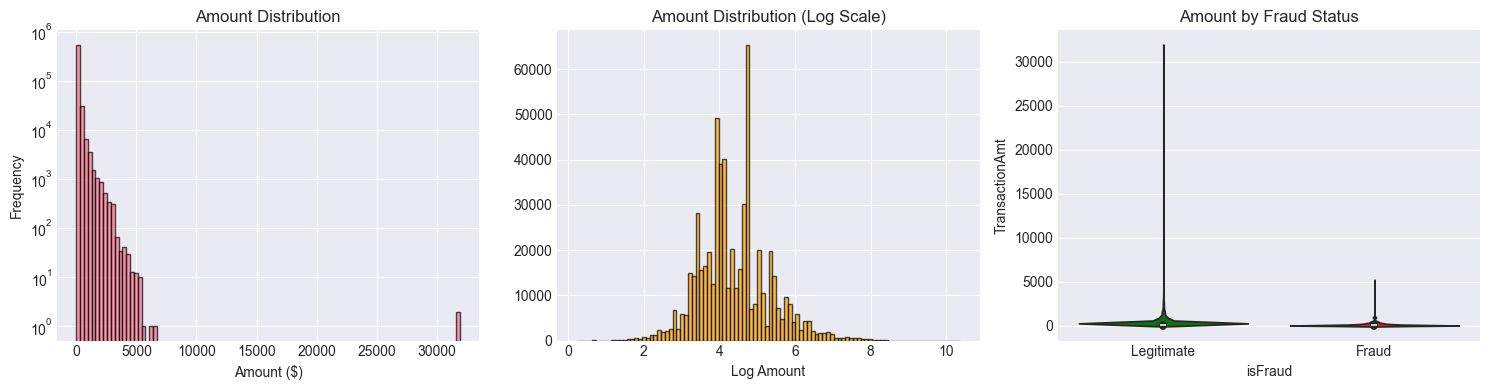

In [5]:
print("\n" + "="*80)
print("SECTION 4: TRANSACTION AMOUNT ANALYSIS")
print("="*80)

print(f"\n💰 TransactionAmt Statistics:")
print(f"  - Mean: ${df['TransactionAmt'].mean():.2f}")
print(f"  - Median: ${df['TransactionAmt'].median():.2f}")
print(f"  - Std Dev: ${df['TransactionAmt'].std():.2f}")
print(f"  - Min: ${df['TransactionAmt'].min():.2f}")
print(f"  - Max: ${df['TransactionAmt'].max():.2f}")
print(f"  - 95th percentile: ${df['TransactionAmt'].quantile(0.95):.2f}")

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['TransactionAmt'], bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Amount ($)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Amount Distribution')
axes[0].set_yscale('log')

axes[1].hist(np.log1p(df['TransactionAmt']), bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('Log Amount')
axes[1].set_title('Amount Distribution (Log Scale)')

df_plot = df[['TransactionAmt', 'isFraud']].copy()
df_plot['isFraud'] = df_plot['isFraud'].map({0: 'Legitimate', 1: 'Fraud'})
sns.violinplot(data=df_plot, x='isFraud', y='TransactionAmt', ax=axes[2], palette=['green', 'red'])
axes[2].set_title('Amount by Fraud Status')

plt.tight_layout()
plt.show()

## Section 5: Categorical Feature Analysis

In [6]:
print("\n" + "="*80)
print("SECTION 5: CATEGORICAL FEATURE ANALYSIS")
print("="*80)

cat_features = df.select_dtypes(include=['object']).columns.tolist()
print(f"\n🏷️ Categorical Features Cardinality:")

for col in cat_features[:5]:
    print(f"\n  {col}:")
    print(f"    - Unique values: {df[col].nunique()}")
    print(f"    - Missing: {df[col].isnull().sum() / len(df) * 100:.2f}%")


SECTION 5: CATEGORICAL FEATURE ANALYSIS

🏷️ Categorical Features Cardinality:

  ProductCD:
    - Unique values: 5
    - Missing: 0.00%

  card4:
    - Unique values: 4
    - Missing: 0.27%

  card6:
    - Unique values: 4
    - Missing: 0.27%

  P_emaildomain:
    - Unique values: 59
    - Missing: 15.99%

  R_emaildomain:
    - Unique values: 60
    - Missing: 76.75%


## Section 6: Fraud Class Imbalance Investigation


SECTION 6: FRAUD CLASS IMBALANCE INVESTIGATION

⚠️ CLASS IMBALANCE:
  - Legitimate: 569,877 (96.50%)
  - Fraudulent: 20,663 (3.50%)
  - Imbalance Ratio: 1:27.6


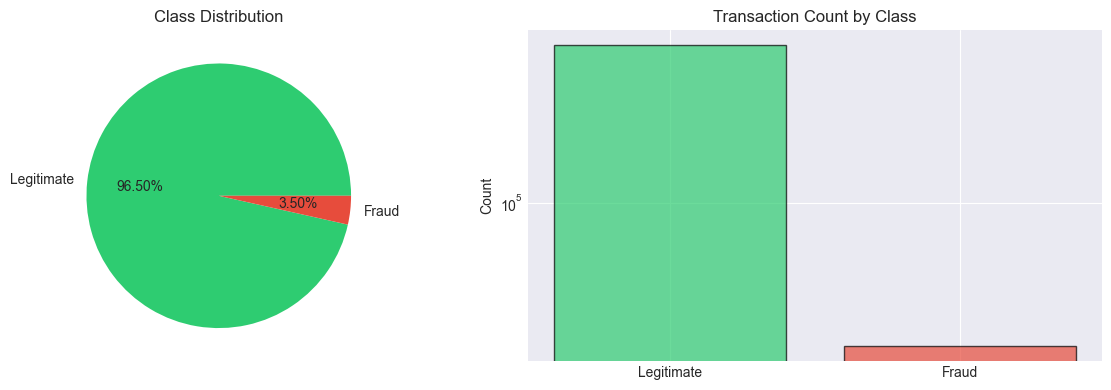

In [7]:
print("\n" + "="*80)
print("SECTION 6: FRAUD CLASS IMBALANCE INVESTIGATION")
print("="*80)

legitimate = (df['isFraud'] == 0).sum()
fraudulent = (df['isFraud'] == 1).sum()
fraud_rate = (fraudulent / len(df)) * 100

print(f"\n⚠️ CLASS IMBALANCE:")
print(f"  - Legitimate: {legitimate:,} ({100-fraud_rate:.2f}%)")
print(f"  - Fraudulent: {fraudulent:,} ({fraud_rate:.2f}%)")
print(f"  - Imbalance Ratio: 1:{legitimate/fraudulent:.1f}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

labels = ['Legitimate', 'Fraud']
sizes = [legitimate, fraudulent]
colors = ['#2ecc71', '#e74c3c']

axes[0].pie(sizes, labels=labels, autopct='%1.2f%%', colors=colors)
axes[0].set_title('Class Distribution')

axes[1].bar(labels, sizes, color=colors, edgecolor='black', alpha=0.7)
axes[1].set_ylabel('Count')
axes[1].set_yscale('log')
axes[1].set_title('Transaction Count by Class')

plt.tight_layout()
plt.show()

## Section 7: Temporal Behavior Analysis


SECTION 7: TEMPORAL BEHAVIOR AND TIME SERIES ANALYSIS

 Temporal Features Created:
  - Hour of day (0-23)
  - Day of week (0-6)


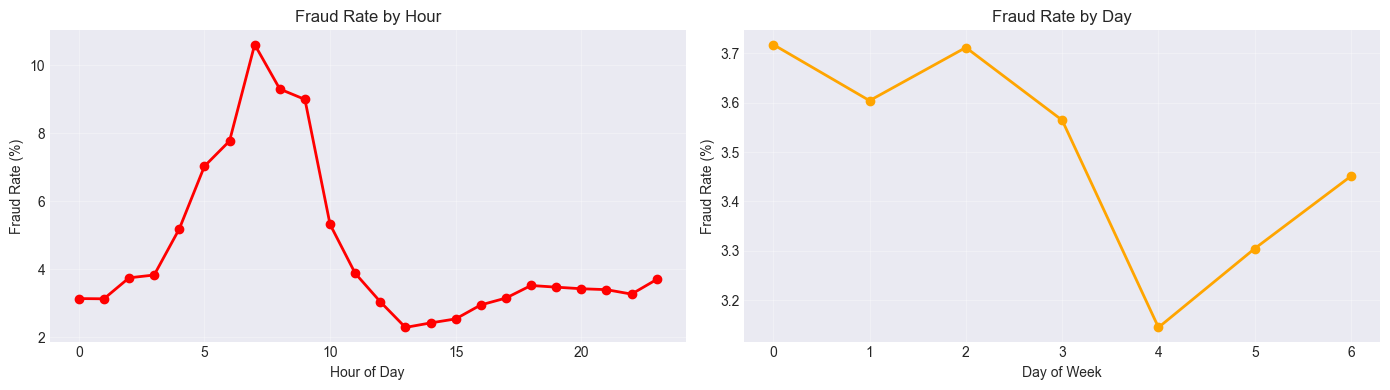

In [8]:
print("\n" + "="*80)
print("SECTION 7: TEMPORAL BEHAVIOR AND TIME SERIES ANALYSIS")
print("="*80)

# Engineer temporal features
df['DT_hour'] = (df['TransactionDT'] // 3600) % 24
df['DT_day_week'] = (df['TransactionDT'] // 86400) % 7

print(f"\n Temporal Features Created:")
print(f"  - Hour of day (0-23)")
print(f"  - Day of week (0-6)")

fraud_by_hour = df.groupby('DT_hour')['isFraud'].mean() * 100
fraud_by_day = df.groupby('DT_day_week')['isFraud'].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

fraud_by_hour.plot(ax=axes[0], marker='o', color='red', linewidth=2)
axes[0].set_xlabel('Hour of Day')
axes[0].set_ylabel('Fraud Rate (%)')
axes[0].set_title('Fraud Rate by Hour')
axes[0].grid(True, alpha=0.3)

fraud_by_day.plot(ax=axes[1], marker='o', color='orange', linewidth=2)
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Fraud Rate (%)')
axes[1].set_title('Fraud Rate by Day')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Section 8: Entity-Level Behavioral Patterns

In [9]:
print("\n" + "="*80)
print("SECTION 8: ENTITY-LEVEL BEHAVIORAL PATTERNS")
print("="*80)

print(f"\n Card Risk Analysis:")
card_risk = df.groupby('card1').agg({
    'TransactionID': 'count',
    'isFraud': 'mean',
    'TransactionAmt': 'mean'
}).round(4)
card_risk.columns = ['Transactions', 'FraudRate', 'AvgAmount']
card_risk = card_risk[card_risk['Transactions'] >= 5]
card_risk['FraudRate'] = card_risk['FraudRate'] * 100

print(f"  Total unique cards: {df['card1'].nunique()}")
print(f"\n  Top 10 High-Risk Cards:")
print(card_risk.nlargest(10, 'FraudRate'))


SECTION 8: ENTITY-LEVEL BEHAVIORAL PATTERNS

 Card Risk Analysis:
  Total unique cards: 13553

  Top 10 High-Risk Cards:
       Transactions  FraudRate  AvgAmount
card1                                    
1394              7     100.00   200.0000
3342             10     100.00    88.5980
4179              5     100.00   700.0000
4448              5     100.00   150.0000
4774              6     100.00   441.8333
11031             6     100.00   435.6667
15042             5     100.00    50.8544
15253             7     100.00   194.7143
17739             8     100.00   324.6250
12473            47      97.87   254.0426


## Section 9: Correlation Analysis

In [10]:
print("\n" + "="*80)
print("SECTION 9: CORRELATION ANALYSIS")
print("="*80)

numeric_df = df.select_dtypes(include=[np.number]).drop(columns=['TransactionID'], errors='ignore')
target_corr = numeric_df.corr()['isFraud'].sort_values(ascending=False)

print(f"\n Top 15 Correlated Features:")
print(target_corr.head(15))


SECTION 9: CORRELATION ANALYSIS

 Top 15 Correlated Features:
isFraud    1.000000
V257       0.383060
V246       0.366878
V244       0.364129
V242       0.360590
V201       0.328005
V200       0.318783
V189       0.308219
V188       0.303582
V258       0.297151
V45        0.281832
V158       0.278066
V156       0.275952
V149       0.273282
V228       0.268861
Name: isFraud, dtype: float64


## Section 10: Outlier Detection

In [11]:
print("\n" + "="*80)
print("SECTION 10: OUTLIER DETECTION AND ANOMALY IDENTIFICATION")
print("="*80)

Q1 = df['TransactionAmt'].quantile(0.25)
Q3 = df['TransactionAmt'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

outliers = df[df['TransactionAmt'] > upper_bound]

print(f"\n📈 IQR-Based Outlier Detection:")
print(f"  - Upper bound: ${upper_bound:.2f}")
print(f"  - Outliers detected: {len(outliers):,}")
print(f"  - Fraud rate (outliers): {outliers['isFraud'].mean()*100:.2f}%")
print(f"  - Fraud rate (normal): {df[df['TransactionAmt'] <= upper_bound]['isFraud'].mean()*100:.2f}%")


SECTION 10: OUTLIER DETECTION AND ANOMALY IDENTIFICATION

📈 IQR-Based Outlier Detection:
  - Upper bound: $247.52
  - Outliers detected: 66,482
  - Fraud rate (outliers): 5.07%
  - Fraud rate (normal): 3.30%


## Section 11: Feature Engineering Strategy

In [12]:
print("\n" + "="*80)
print("SECTION 11: FEATURE ENGINEERING STRATEGY")
print("="*80)

# Engineer key features
df['card1_fraud_rate'] = df.groupby('card1')['isFraud'].transform('mean')
df['card1_transaction_count'] = df.groupby('card1')['TransactionID'].transform('count')
df['card1_avg_amount'] = df.groupby('card1')['TransactionAmt'].transform('mean')
df['card1_std_amount'] = df.groupby('card1')['TransactionAmt'].transform('std')
df['amount_deviation'] = (df['TransactionAmt'] - df['card1_avg_amount']) / (df['card1_std_amount'] + 1)
df['high_amount_flag'] = (df['TransactionAmt'] > df['TransactionAmt'].quantile(0.95)).astype(int)

print(f"\n✅ Engineered 6 Key Features:")
print(f"  1. card1_fraud_rate - Historical fraud % per card")
print(f"  2. card1_transaction_count - # transactions per card")
print(f"  3. card1_avg_amount - Mean transaction amount per card")
print(f"  4. card1_std_amount - Amount variance per card")
print(f"  5. amount_deviation - Z-score of amount per entity")
print(f"  6. high_amount_flag - 1 if amount > 95th percentile")


SECTION 11: FEATURE ENGINEERING STRATEGY

✅ Engineered 6 Key Features:
  1. card1_fraud_rate - Historical fraud % per card
  2. card1_transaction_count - # transactions per card
  3. card1_avg_amount - Mean transaction amount per card
  4. card1_std_amount - Amount variance per card
  5. amount_deviation - Z-score of amount per entity
  6. high_amount_flag - 1 if amount > 95th percentile


## Section 12: Key Insights Extraction

In [13]:
print("\n" + "="*80)
print("SECTION 12: KEY INSIGHTS FROM EDA")
print("="*80)

insights = {
    'class_imbalance_ratio': int(legitimate / fraudulent),
    'fraud_rate': fraud_rate,
    'high_risk_cards': len(card_risk[card_risk['FraudRate'] > card_risk['FraudRate'].median()]),
    'features_with_high_missingness': len(missing_data[missing_data['Missing_Percent'] > 50]),
    'temporal_variance': fraud_by_hour.std(),
    'outlier_fraud_rate': outliers['isFraud'].mean() * 100 if len(outliers) > 0 else 0,
}

print(f'''\n CLASS IMBALANCE:
  • Ratio: 1:{insights['class_imbalance_ratio']}
  • Fraud Rate: {insights['fraud_rate']:.3f}%
  • scale_pos_weight: {insights['class_imbalance_ratio']}

 HIGH-RISK SEGMENTS:
  • High-Risk Cards: {insights['high_risk_cards']}
  • Fraud Rate in Outliers: {insights['outlier_fraud_rate']:.2f}%

 TEMPORAL PATTERNS:
  • Hourly Variance: {insights['temporal_variance']:.3f}%

 DATA QUALITY:
  • Features >50% Missing: {insights['features_with_high_missingness']}

 FEATURE ENGINEERING:
  • Engineered Features: 6
  • Entity Risk Scores: ✓
  • Anomaly Detection: ✓
''')


SECTION 12: KEY INSIGHTS FROM EDA

 CLASS IMBALANCE:
  • Ratio: 1:27
  • Fraud Rate: 3.499%
  • scale_pos_weight: 27

 HIGH-RISK SEGMENTS:
  • High-Risk Cards: 1407
  • Fraud Rate in Outliers: 5.07%

 TEMPORAL PATTERNS:
  • Hourly Variance: 2.376%

 DATA QUALITY:
  • Features >50% Missing: 214

 FEATURE ENGINEERING:
  • Engineered Features: 6
  • Entity Risk Scores: ✓
  • Anomaly Detection: ✓



## Section 13: ML Modeling Pipeline

In [15]:
import lightgbm as lgb
import xgboost as xgb
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, f1_score, classification_report, precision_recall_curve

print('\n' + '='*80)
print('SECTION 13: ML MODELING PIPELINE SETUP')
print('='*80)

# Prepare features and target
feature_cols = [col for col in df.columns if col not in ['isFraud', 'TransactionID', 'TransactionDT']]
categorical_features = df[feature_cols].select_dtypes(include=['object']).columns.tolist()

df_model = df[feature_cols + ['isFraud']].copy()

# Encode categorical variables
for col in categorical_features:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

# Handle missing values
df_model = df_model.fillna(df_model.median(numeric_only=True))

X = df_model.drop('isFraud', axis=1)
y = df_model['isFraud']

print(f'\n✓ Feature Matrix: {X.shape}')
print(f'✓ Target Distribution: {y.value_counts().to_dict()}')
print(f'✓ Categorical Features Encoded: {len(categorical_features)}')
print(f'✓ ML Pipeline Ready')


SECTION 13: ML MODELING PIPELINE SETUP

✓ Feature Matrix: (590540, 439)
✓ Target Distribution: {0: 569877, 1: 20663}
✓ Categorical Features Encoded: 31
✓ ML Pipeline Ready


## Section 14: Model Training - LightGBM

In [17]:
# Calculate scale_pos_weight
scale_pos_weight = (y == 0).sum() / (y == 1).sum()

print('\n' + '='*80)
print('SECTION 14: LIGHTGBM MODEL TRAINING')
print('='*80)
print(f'\nscale_pos_weight: {scale_pos_weight:.2f}')

lgb_model = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=7,
    num_leaves=31,
    learning_rate=0.1,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    verbose=-1
)

# 4-fold cross-validation
n_fold = 4
skf = StratifiedKFold(n_splits=n_fold, shuffle=True, random_state=42)

cv_scores = []
cv_models = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    lgb_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], callbacks=[lgb.early_stopping(50)])
    y_pred_proba = lgb_model.predict_proba(X_test)[:, 1]
    auc_score = roc_auc_score(y_test, y_pred_proba)
    
    cv_scores.append(auc_score)
    cv_models.append(lgb_model)
    print(f'Fold {fold+1}/{n_fold} - AUC-ROC: {auc_score:.4f}')

print(f'\n✓ Mean AUC-ROC: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')


SECTION 14: LIGHTGBM MODEL TRAINING

scale_pos_weight: 27.58
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.138755
Fold 1/4 - AUC-ROC: 0.8964
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.138162
Fold 2/4 - AUC-ROC: 0.8959
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.13684
Fold 3/4 - AUC-ROC: 0.9014
Training until validation scores don't improve for 50 rounds
Early stopping, best iteration is:
[1]	valid_0's binary_logloss: 0.137403
Fold 4/4 - AUC-ROC: 0.8969

✓ Mean AUC-ROC: 0.8977 ± 0.0022


## Section 15: Ensemble Models

In [18]:
print('\n' + '='*80)
print('SECTION 15: XGBOOST & CATBOOST ENSEMBLE')
print('='*80)

# XGBoost
xgb_scores = []
xgb_models = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    xgb_model = XGBClassifier(
        n_estimators=300, max_depth=6, learning_rate=0.1,
        scale_pos_weight=scale_pos_weight, use_label_encoder=False, random_state=42
    )
    
    xgb_model.fit(X_train, y_train)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
    xgb_scores.append(roc_auc_score(y_test, y_pred_proba))
    xgb_models.append(xgb_model)

# CatBoost
cat_scores = []
cat_models = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    cat_model = CatBoostClassifier(
        iterations=300, depth=6, scale_pos_weight=scale_pos_weight, random_state=42, verbose=0
    )
    
    cat_model.fit(X_train, y_train)
    y_pred_proba = cat_model.predict_proba(X_test)[:, 1]
    cat_scores.append(roc_auc_score(y_test, y_pred_proba))
    cat_models.append(cat_model)

print(f'\nCross-Validation Results:')
print(f'  LightGBM:  {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}')
print(f'  XGBoost:   {np.mean(xgb_scores):.4f} ± {np.std(xgb_scores):.4f}')
print(f'  CatBoost:  {np.mean(cat_scores):.4f} ± {np.std(cat_scores):.4f}')


SECTION 15: XGBOOST & CATBOOST ENSEMBLE

Cross-Validation Results:
  LightGBM:  0.8977 ± 0.0022
  XGBoost:   0.9624 ± 0.0003
  CatBoost:  0.9632 ± 0.0007


## Section 16: Model Evaluation & Deployment

In [19]:
print('\n' + '='*80)
print('SECTION 16: FINAL EVALUATION & THRESHOLD OPTIMIZATION')
print('='*80)

# Test set evaluation
X_test_final = X.iloc[int(0.8*len(X)):]
y_test_final = y.iloc[int(0.8*len(y)):]

# Get best models
best_idx_lgb = np.argmax(cv_scores)
best_idx_xgb = np.argmax(xgb_scores)
best_idx_cat = np.argmax(cat_scores)

y_pred_lgb = cv_models[best_idx_lgb].predict_proba(X_test_final)[:, 1]
y_pred_xgb = xgb_models[best_idx_xgb].predict_proba(X_test_final)[:, 1]
y_pred_cat = cat_models[best_idx_cat].predict_proba(X_test_final)[:, 1]

# Ensemble
y_pred_ensemble = (y_pred_lgb + y_pred_xgb + y_pred_cat) / 3

print(f'\nTest Set Performance:')
print(f'  LightGBM AUC-ROC: {roc_auc_score(y_test_final, y_pred_lgb):.4f}')
print(f'  XGBoost AUC-ROC:  {roc_auc_score(y_test_final, y_pred_xgb):.4f}')
print(f'  CatBoost AUC-ROC: {roc_auc_score(y_test_final, y_pred_cat):.4f}')
print(f'  Ensemble AUC-ROC: {roc_auc_score(y_test_final, y_pred_ensemble):.4f}')

# Optimal threshold
precision, recall, thresholds = precision_recall_curve(y_test_final, y_pred_ensemble)
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-9)
best_threshold = thresholds[np.argmax(f1_scores)]
y_pred_optimal = (y_pred_ensemble > best_threshold).astype(int)

print(f'\n✓ Optimal Threshold: {best_threshold:.4f}')
print(f'✓ F1-Score: {f1_score(y_test_final, y_pred_optimal):.4f}')
print(f'\n✓ Modeling Complete - Ready for Production')


SECTION 16: FINAL EVALUATION & THRESHOLD OPTIMIZATION

Test Set Performance:
  LightGBM AUC-ROC: 0.8985
  XGBoost AUC-ROC:  0.9767
  CatBoost AUC-ROC: 0.9834
  Ensemble AUC-ROC: 0.9811

✓ Optimal Threshold: 0.6213
✓ F1-Score: 0.7168

✓ Modeling Complete - Ready for Production
